# Water Quality Assessment using Implicative Fuzzy Inference Systems
**Project Overview:** This notebook implements a fuzzy logic-based approach to evaluate river water quality based on physical and chemical parameters. It utilizes an **Implicative Inference System** to map environmental data (such as oxygen levels, nitrogen, and phosphorus) to quality categories ranging from "Very Good" to "Very Bad".

### Key Features:
* **Data Processing:** Loads and filters river quality datasets (`River_quality_data_2023.csv`) and predefined quality intervals (`Phisical_Chemical_quality_intervals.csv`).
* **Fuzzy Inference:** Implements an `ImplicativeInferenceSystem` using Łukasiewicz t-norms and alternative modifiers.
* **Defuzzification Analysis:** Compares different defuzzification methods, specifically **Center of Gravity (CoG)** and **Mean of Maxima (MoM)**.
* **Decision Support:** Includes a "Payoff" analysis to evaluate the economic or environmental benefits of taking action (e.g., water cleaning) versus no action under varying levels of uncertainty.
* **Visualization:** Provides detailed plotting functions for membership functions, payoff heatmaps, and defuzzification comparisons.



In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import find_peaks

from fuzzy_inference.fuzzy_utils.alpha_cuts import create_1d_hat_function_scipy 
from fuzzy_inference.payoff_function.simple_payoff_functions import simple_payoff_function
from fuzzy_inference.rule_bases.Implicative_model import ImplicativeInferenceSystem

In [2]:
# Read the data for water quality
df_water_data = pd.read_csv(
    '../Data/River_quality_data_2023.csv',
    delimiter=',', 
    decimal=',' 
)
 

In [3]:
# Reads the data for quality intervals
df_quaity_intervals = pd.read_csv(
    '../Data/Phisical_Chemical_quality_intervals.csv',
    delimiter=';',
    encoding='windows-1252',   
    decimal=',' 
)

In [4]:
def filter_qualityGrid_from_data(water_type = 1):
    filtered_intervals = df_quaity_intervals[df_quaity_intervals['Tips'] == water_type]

    # Select only numeric columns from the filtered data
    numeric_data = filtered_intervals.select_dtypes(include='number').drop(columns=['Tips'])

    # Sort the values in each row and create a new DataFrame
    return pd.DataFrame(
        np.sort(numeric_data.values, axis=1), 
        index=numeric_data.index, 
        columns=numeric_data.columns
    ).values

In [5]:
from matplotlib.pyplot import grid


def plot_membership_function(membership_value, output_center_of_gravity, mean_of_maxima,
                             grid = np.array([0, 0.25, 0.5, 0.75, 1]), crips_center = None, title = ''):
    """Function for plotting the membership function with deffuzified values 
    and intervals for crisp quality assessments.

    Args:
        membership_value (np.ndarray): contains the values of the membership function.
        output_center_of_gravity (float): the center of gravity value.
        mean_of_maxima (float): the mean of maxima value.
        grid (np.array, optional): the grid for quality intervals. 
        crips_center (float): The crisp evaluation point
        title (strl): title for the plot
    """    
 
    interval_colors = [
        '#00BFFF',  # Very good
        '#90EE90',  # Good
        '#FFFF00',  # Medium
        '#FFA500',  # Bad
        '#FF0000',  # Very bad
    ]
    
    for i in range(len(grid) - 1):
    
        if i == 0:
            plt.hlines(y=-0.007, xmin=grid[i], xmax=(grid[i]+grid[i+1])/2, colors=interval_colors[i], linewidth=5) 
        else:
            plt.hlines(y=-0.007, xmin=(grid[i-1]+grid[i])/2, xmax=(grid[i]+grid[i+1])/2, colors=interval_colors[i], linewidth=5)
    
    plt.hlines(y=-0.007, xmin=(grid[-1]+grid[-2])/2, xmax=grid[-1], colors=interval_colors[-1], linewidth=5)

    plt.plot(np.linspace(0.005, 1, membership_value.shape[0]), membership_value, label='Piederības funkcija',  linewidth=3)
    plt.xlabel('Ūdens kvalitāte', fontsize=16)
    plt.ylabel('Piederības pakāpe', fontsize=16)
    # plt.title(f"Membership value for {title}",fontsize=18)
    plt.axvline(output_center_of_gravity, color='blue', linestyle='--', label=f'Masas centrs: {output_center_of_gravity:.3f}')
    plt.axvline(mean_of_maxima, color='green', linestyle='--', label=f'Vidējais no maksimuma {mean_of_maxima:.3f}')
    # if crips_center is not None:
    #     plt.axvline(crips_center, color='green', linestyle='--', label=f'Crisp evaluation {crips_center:.3f}')
    plt.grid(True)
    plt.legend(loc='upper left', fontsize=12)
    plt.tick_params(axis='both', which='major', labelsize=14)
    plt.show()

In [6]:
def plot_payoff_plots(data1, title1, data2, title2, N_i_vals, c_i_vals, mid_point_N, midpoint_c):
    """Function for making the heatmaps of payoff plots. 
    
    Here data_1 is payoff using center of gravity defuzzification
    and data_2 is payoff using mean of maxima defuzzification.

    Args:
        data1 (np.ndarray): NxN array of payoff values. (CoG)
        title1 (str): Title for the first plot.
        data2 (np.ndarray): NxN array of payoff values. (MOM)
        title2 (str): Title for the second plot.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               
        N_i_vals (np.ndarray): The grid values for N_i parameter. (X axis)
        c_i_vals (np.ndarray): The grid values for c_i parameter. (Y axis)
        mid_point_N (float): The midpoint value for N_i parameter. (used in Title)
        midpoint_c (float): The midpoint value for c_i parameter. (used in Title)
    """    
    
    # Create a figure and a set of subplots (1 row, 2 columns)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7)) # Adjust figsize for better display
    
    # Calculate extent for correct axis scaling and labeling
    N_i_step = N_i_vals[1] - N_i_vals[0]
    c_i_step = c_i_vals[1] - c_i_vals[0]
    
    extent = [
        N_i_vals[0] - N_i_step / 2, # xmin
        N_i_vals[-1] + N_i_step / 2, # xmax
        c_i_vals[0] - c_i_step / 2, # ymin
        c_i_vals[-1] + c_i_step / 2  # ymax
    ]
    
    # --- Plot 1: payoff for CoG
    ax1 = axes[0]
    im1 = ax1.imshow(
        data1, 
        aspect='auto', 
        origin='lower', 
        extent=extent,
        cmap='plasma'  
    )
    fig.colorbar(im1, ax=ax1, label='Calculated COG Value')
    ax1.set_title(title1, fontsize=21)
    ax1.set_xlabel(r'$N_i$ (Parameter)', fontsize=16)
    ax1.set_ylabel(r'$c_i$ (Parameter)', fontsize=16)
    ax1.set_xticks(N_i_vals[::10])  
    ax1.set_yticks(c_i_vals[::10])
    ax1.grid(which='major', color='white', linestyle=':', linewidth=0.5, alpha=0.5)

    
    # --- Plot 2: payoff for MoM
    ax2 = axes[1]
    im2 = ax2.imshow(
        data2, 
        aspect='auto', 
        origin='lower', 
        extent=extent, 
        cmap='plasma'  
    )
    fig.colorbar(im2, ax=ax2, label='Calculated COG Value')
    ax2.set_title(title2, fontsize=21)
    ax2.set_xlabel(r'$N_i$ (Parameter)', fontsize=16)
    ax2.set_xticks(N_i_vals[::10])
    ax2.set_yticks(c_i_vals[::10])
    ax2.grid(which='major', color='white', linestyle=':', linewidth=0.5, alpha=0.5)
    fig.suptitle(f'Comparison of COG and MOM across Parameters $N_i$ and $c_i$ with $N_m$ = {mid_point_N}, $c_m$ = {midpoint_c}', fontsize=16)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96]) 
    plt.show()
 

In [7]:

def plot_defuzzification_comparison(
    x_grid_taking_NxMu, mu_curve_taking_NxMu, cog_taking_action_NxMu, x_of_maxima_NxMu,
    x_grid_taking_N_MuC, mu_curve_taking_N_MuC, cog_taking_action_N_MuC, x_of_maxima_N_MuC,
):
    """
    Generates a figure with side-by-side subplots comparing different defuzzification 
    curves and their Center of Gravity (CoG) and Mean of Maxima (MoM) results.

    Arguments must be provided as NumPy arrays or scalar floats/arrays as used in the plot calls.
    (MoM arguments are expected to be arrays that can be indexed or squeezed).
    """
    
    # Set the overall size of the plot window
    plt.figure(figsize=(18, 5))  

    # --- Plot 1 (Left): mu * payoff ---
    plt.subplot(1, 2, 1)  
    plt.plot(x_grid_taking_NxMu, mu_curve_taking_NxMu,  linewidth=2)

    # CoG Annotation
    plt.axvline(x=cog_taking_action_NxMu, color='blue', label=f'CoG {cog_taking_action_NxMu:.3f}', linewidth=2)
    plt.text(cog_taking_action_NxMu + 1, np.min(mu_curve_taking_NxMu) + 0.1, 
             f'CoG: {cog_taking_action_NxMu:.2f}', color='blue', 
             rotation='vertical', fontsize=12)  
 
    mom_nxmu_val = x_of_maxima_NxMu.squeeze()
    # MoM Annotation
    plt.axvline(x=mom_nxmu_val, color='green', label=f'MoM - {mom_nxmu_val:.3f}', linewidth=2)
    plt.text(mom_nxmu_val - 5, np.min(mu_curve_taking_NxMu) + 0.1, 
             f'MoM: {mom_nxmu_val:.2f}', color='green', 
             rotation='vertical', fontsize=12)

    plt.title(r'$N \cdot (1 - \mu )$', fontsize=20)
    plt.xlabel('EUR', fontsize=20)
    plt.ylabel('Membership degree', fontsize=20)
    plt.legend(fontsize = 16) 
    plt.grid(True)
    plt.xticks(fontsize = 16)
    plt.yticks(fontsize = 16)

    # --- Plot 2 (Right): payoff - mu * cleaning cost
    plt.subplot(1, 2, 2)  
    plt.plot(x_grid_taking_N_MuC, mu_curve_taking_N_MuC,  linewidth=2)
    
    # CoG Annotation
    plt.axvline(x=cog_taking_action_N_MuC, color='blue', label=f'CoG - {cog_taking_action_N_MuC:.3f}', linewidth=2)
    plt.text(cog_taking_action_N_MuC + 1, np.min(mu_curve_taking_N_MuC) + 0.1, 
             f'CoG: {cog_taking_action_N_MuC:.2f}', color='blue', 
             rotation='vertical', fontsize=12)

    # MoM Annotation
    mom_nmuc_val = x_of_maxima_N_MuC.squeeze()
    plt.axvline(x=mom_nmuc_val, color='green', label=f'MoM - {mom_nmuc_val:.3f}', linewidth=2)
    plt.text(mom_nmuc_val - 5, np.min(mu_curve_taking_N_MuC) + 0.1, 
             f'MoM: {mom_nmuc_val:.2f}', color='green', 
             rotation='vertical', fontsize=12)
             
    plt.title(r'$ N - \mu c $', fontsize=20)
    plt.xlabel('EUR', fontsize=20)
    plt.legend(fontsize = 16)
    plt.grid(True)
    plt.xticks(fontsize = 16)
    plt.yticks(fontsize = 16)

    plt.tight_layout() 
    plt.show()

In [8]:
def perform_infernece_and_evaluation_with_data(data_sample, data_type = 1, step_size = 5, Number_of_grid_points = 100,
                                               payoff_membership_vaues = np.array([90, 100, 110]), cleaning_cost_membership_values = np.array([75, 80 , 85]),
                                               type_of_tnorm = 'luk', sample_name = 'dummy_sample', use_the_same_tnorm = False):
    """ This function pperforms: 
            1. inference on the passed data nad plots the membership function
            2. Given passed payoff and cleaning cost membership functions, 
            it calculates the payoff values for both taking and not taking action
            given a basic payoff function - Payoff - membership value * cleaning cost, if clening the water or 
            membership value * payoff, if not cleaning the water.
            3. Performs an analysis of payoff, given a different amount of unvertainty in both payoff and cleaning costs. 
    
    The sample data is in order: BSP5 N_NH4+ N_total O_2 P_total
    
    Args:
        data_sample (np.ndarray): Sample data for inference. 
        data_type (int): River type. Used to extract correct quality grid
        step_size (int): Step size over the uncertainty grid for payoff and cleaning cost
        Number_of_grid_points (int): Grid points for inference and payoff calculations
        sample_name (str): Title for the plots. 
    """    
    # First perform inference
    type_1_qualityGrid = filter_qualityGrid_from_data(water_type=data_type)
    type_1_system = ImplicativeInferenceSystem(type_1_qualityGrid, type_of_modifier='altm',
                                               number_of_grid_points=Number_of_grid_points,
                                               type_of_tnorm=type_of_tnorm, aggregate_with_same_tnorm=use_the_same_tnorm)
    output_center_of_gravity, membership_value  = type_1_system.inference(data_sample)
    
    # Find peaks in the membership function and calculate mean of maxima
    peak_indices, _ = find_peaks(membership_value)
    if peak_indices.size == 0:
        # In case there are no peaks, check the endpoints. 
        if membership_value[0] > membership_value[-1]:
            mean_of_maxima = [0]
        else:
            mean_of_maxima = [1]
    else:
        mean_of_maxima = np.linspace(0, 1, Number_of_grid_points)[peak_indices]

    print(f"The membership function of sample {sample_name}: ")
    plot_membership_function(membership_value, output_center_of_gravity, mean_of_maxima[0], title=sample_name)
    
    # Defone the membership functions for payoff and cleaning costs
    N = create_1d_hat_function_scipy(payoff_membership_vaues, 1)
    C = create_1d_hat_function_scipy(cleaning_cost_membership_values, 1)
    
    # Calculate the payff values for both taking and not taking the action
    calculate_the_payoff_values = simple_payoff_function(membership_value,  N, C,
                                                         Cores =[[payoff_membership_vaues[1], payoff_membership_vaues[1]],
                                                                                          [cleaning_cost_membership_values[1], cleaning_cost_membership_values[1]]],
                                                         Number_of_grid_points = Number_of_grid_points,
                                                         N_range=[payoff_membership_vaues[0], payoff_membership_vaues[2]],
                                                         c_range=[cleaning_cost_membership_values[0], cleaning_cost_membership_values[2]])
    # Take the both payoff values with deffuzified values
    cog_taking_action_NxMu, mu_curve_taking_NxMu, x_grid_taking_NxMu, x_of_maxima_NxMu = calculate_the_payoff_values['Taking_no_action']
    cog_taking_action_N_MuC, mu_curve_taking_N_MuC, x_grid_taking_N_MuC, x_of_maxima_N_MuC = calculate_the_payoff_values['Taking_action']
    
    print("Plotting comparison between the payoff of perfomring an action and not performing an action:")
    plot_defuzzification_comparison(
        x_grid_taking_NxMu, mu_curve_taking_NxMu, cog_taking_action_NxMu, x_of_maxima_NxMu,
        x_grid_taking_N_MuC, mu_curve_taking_N_MuC, cog_taking_action_N_MuC, x_of_maxima_N_MuC,
    )
    
    # return None
    
    # Define the middle points for payoff and cleaning cost
    c_M = 80
    N_m = 100

    # Define the grid for amount of uncertainty for both payoff and cleaning cost
    N_i_values = np.arange(2, 100, step_size)  # X-axis values
    c_i_values = np.arange(2, 70, step_size)   # Y-axis values

    results_cog = np.zeros((len(c_i_values), len(N_i_values)))
    results_MOM = np.zeros((len(c_i_values), len(N_i_values)))

    print("Plotting the payoff for differentt amounts of uncertainty. The choice between taking and not taking action is based on taking maximum of defuziffied values.")
    for j, c_i in enumerate(c_i_values): # j is the row index (Y-axis)
        for i, N_i in enumerate(N_i_values):  # i is the column index (X-axis)
            N = create_1d_hat_function_scipy(np.array([N_m - N_i, N_m, N_m + N_i]), 1)
            C = create_1d_hat_function_scipy(np.array([c_M - c_i, c_M , c_M + c_i]), 1)
            calculate_the_payoff_values = simple_payoff_function(membership_value,  N = N, c = C, Number_of_grid_points = Number_of_grid_points,
                                                                 Cores =[[N_m, N_m], [c_M, c_M]],
                                                                 N_range=[N_m - N_i, N_m + N_i], c_range=[c_M - c_i, c_M + c_i])
            cog_taking_action_NxMu, _, _, x_of_maxima_NxMu = calculate_the_payoff_values['Taking_no_action']
            cog_taking_action_N_MuC, _, _, x_of_maxima_N_MuC = calculate_the_payoff_values['Taking_action'] 
                         
            # Save the maximum of both defuzified values as the payoff   
            results_cog[j, i] = np.maximum(cog_taking_action_NxMu.item(), cog_taking_action_N_MuC.item())
            results_MOM[j, i] = np.maximum(x_of_maxima_NxMu.item(), x_of_maxima_N_MuC.item())
            
    # plots both grids of payoff values 
    plot_payoff_plots(
        results_cog, 
        r'COG',  
        results_MOM, 
        r'MOM',
        N_i_values, 
        c_i_values,
        N_m,
        c_M
    )

The membership function of sample G327 (Gosupe, grīva): 


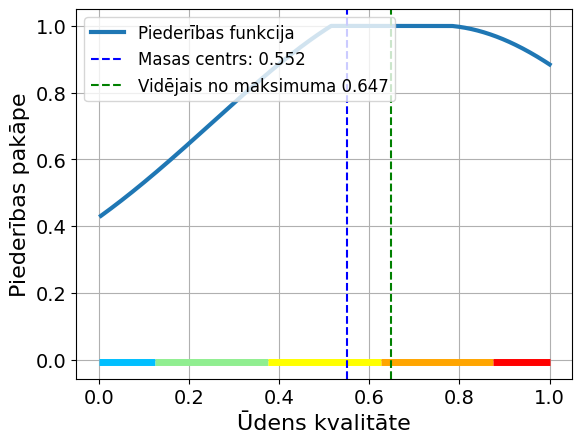

Plotting comparison between the payoff of perfomring an action and not performing an action:


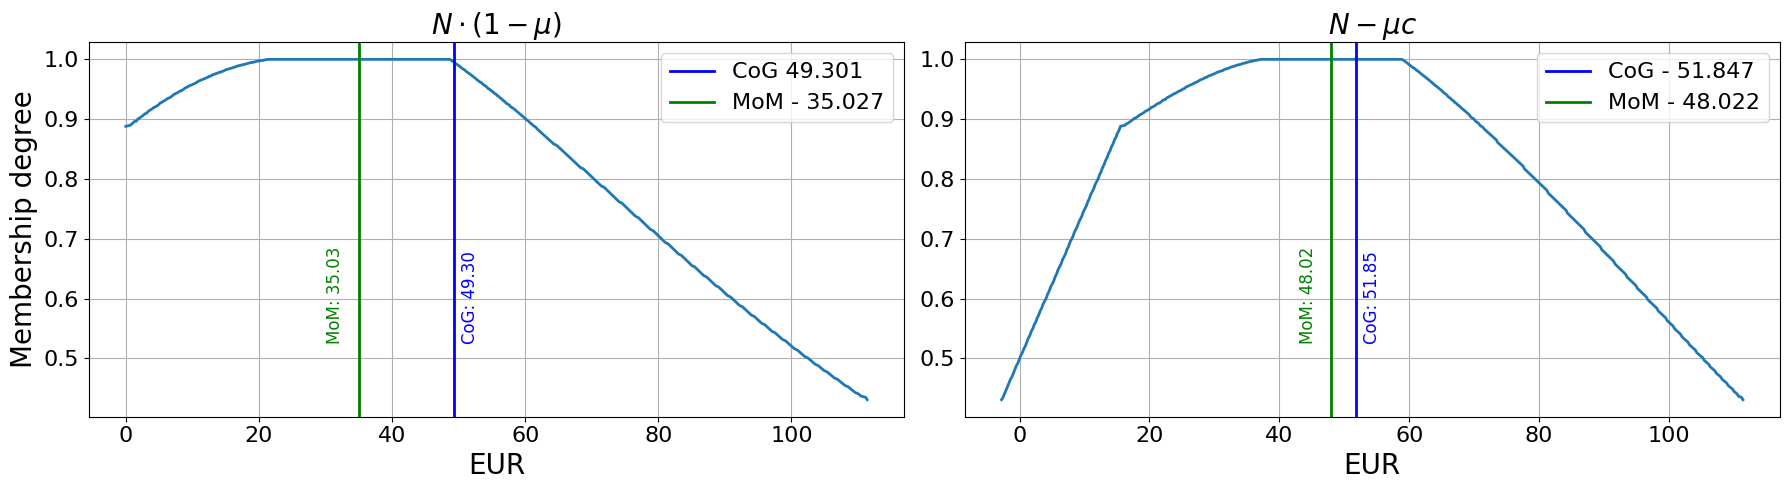

Plotting the payoff for differentt amounts of uncertainty. The choice between taking and not taking action is based on taking maximum of defuziffied values.


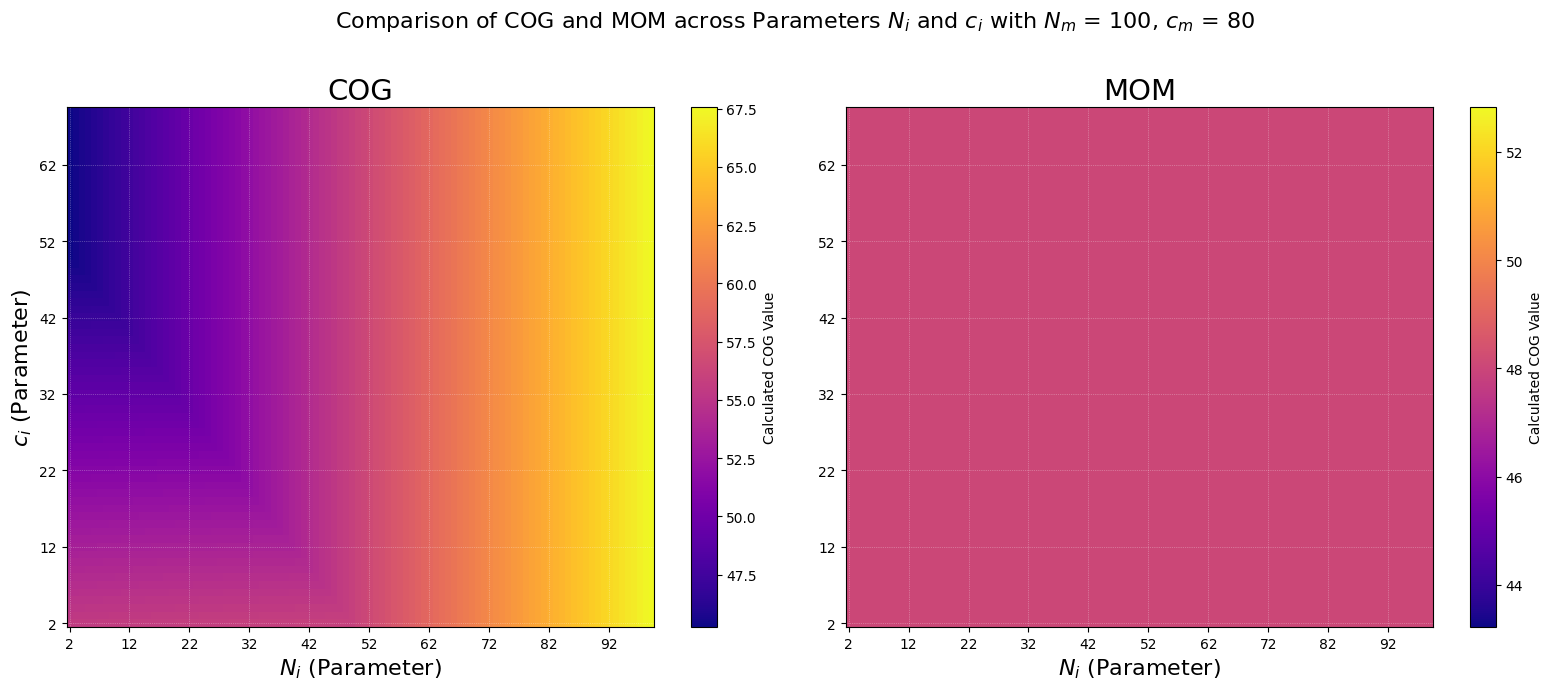

In [9]:
# Example of usage the Gosupe data.
first_r7 = df_water_data[df_water_data['Station_type'] == 'R1'].iloc[0]  
type_1_qualityGrid = filter_qualityGrid_from_data(water_type=1)
Number_of_grid_points = 500
sample = first_r7.iloc[-5:].values.astype(float)
sample[3] = type_1_qualityGrid[3,-1] - sample[3] + type_1_qualityGrid[3,0] # The O_2 levels are being inverted, as they have reversed order.

perform_infernece_and_evaluation_with_data(sample, step_size=1,
                                           Number_of_grid_points=Number_of_grid_points,
                                           sample_name='G327 (Gosupe, grīva)', type_of_tnorm='luk',
                                           payoff_membership_vaues = np.array([80, 100, 120]),
                                           cleaning_cost_membership_values = np.array([60, 80 , 100]))

##  Comparing results from other stations

| Station name | O₂, mg/l O₂ | BSP₅, mg/l O₂ | N/NH₄⁺, mg/L | N_total, mg/L | P_total, mg/L | Final quality |
| :----------- | :---------- | :------------ | :----------- | :------------ | :------------ | :------------ |
| Taļķe, grīva L132 | 8.5 (Very good) | 2.17 (Good)   | 0,347 (Very Bad) | 3,58 (Very Bad)  | 0,066 (Good) | Very Bad (5) |
| Skujaine, grīva L121 | 10,7 (Very Good) | 1,19 (Very Good)   | 0,071 (Very Good) | 5,76 (Very Bad)  | 0,035 (Very Good) | Very Bad (5)|
| Ezere, grīva V063DA | 9.5 (Very Good) | 1,36 (Very Good)   | 0,025  (Very Good) | 3,5 (Very Bad)  | 0,032 (Very Good) | Very Bad (5)|
| Stende, augštece V138 | 10.5 (Very Good) | 1,86 (Very Good)   | 0,051  (Very Good) | 2,36 (Medium)  | 0,077 (Medium) | Medium (3)|

In [10]:
### L132 # 
comparison_df = pd.DataFrame(columns=(df_water_data.columns))
L132_data= {
    'Code': 'L132',
    'Station_type': 3,
    'BSP5': 2.17,
    'N_NH4+': 0.347,
    'N_total': 3.580,
    'O_2': 8.5,
    'P_total': 0.066,
    'Station name': 'Taļķe, grīva L132'
}
comparison_df.loc[len(comparison_df)] = L132_data 

# L121
L121_data = {
    'Code': 'L121',
    'Station_type': 3,
    'BSP5': 1.19,
    'N_NH4+': 0.071,
    'N_total': 5.760,          
    'O_2': 10.7,
    'P_total': 0.035,
    'Station name': 'Skujaine, grīva L121'
}
comparison_df.loc[len(comparison_df)] = L121_data

# V063DA
V063DA_data = {
    'Code': 'V063DA',
    'Station_type': 3,
    'BSP5': 1.36,
    'N_NH4+': 0.025,
    'N_total': 3.5,          
    'O_2': 9.5,
    'P_total': 0.032,
    'Station name': 'Ezere, grīva V063DA'
}
comparison_df.loc[len(comparison_df)] = V063DA_data

# V138
V138_data = {
    'Code': 'V138',
    'Station_type': 1,
    'BSP5': 1.86,
    'N_NH4+': 0.051,
    'N_total': 2.36,          
    'O_2': 10.5,
    'P_total': 0.077,
    'Station name': 'Stende, augštece V138'
}
comparison_df.loc[len(comparison_df)] = V138_data

type_1_qualityGrid = filter_qualityGrid_from_data(water_type=1)
type_3_qualityGrid = filter_qualityGrid_from_data(water_type=3)

# O2 column
column_name_to_update = comparison_df.columns[4]

# Flips the O2 value based on station type
constant_sum_type1 = type_1_qualityGrid[3, -1] + type_1_qualityGrid[3, 0]
constant_sum_type3 = type_3_qualityGrid[3, -1] + type_3_qualityGrid[3, 0]
condition_column = 'Station_type'

# Condition based on station type. 
conditional_constant = np.where( 
    comparison_df[condition_column] == 'R3',   
    constant_sum_type3,                      
    constant_sum_type1                        
)

#  Perform the final vectorized calculation using the new conditional_constant Series
comparison_df[column_name_to_update] = conditional_constant - comparison_df[column_name_to_update]
print(comparison_df)
 

     Code  Station_type  BSP5  N_NH4+  N_total   O_2  P_total
0    L132             3  2.17   0.347     6.42   8.5    0.066
1    L121             3  1.19   0.071     4.24  10.7    0.035
2  V063DA             3  1.36   0.025     6.50   9.5    0.032
3    V138             1  1.86   0.051     7.64  10.5    0.077


The membership function of sample L132: 


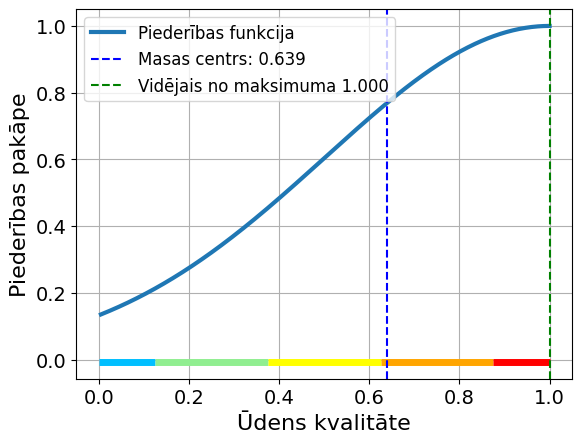

Plotting comparison between the payoff of perfomring an action and not performing an action:


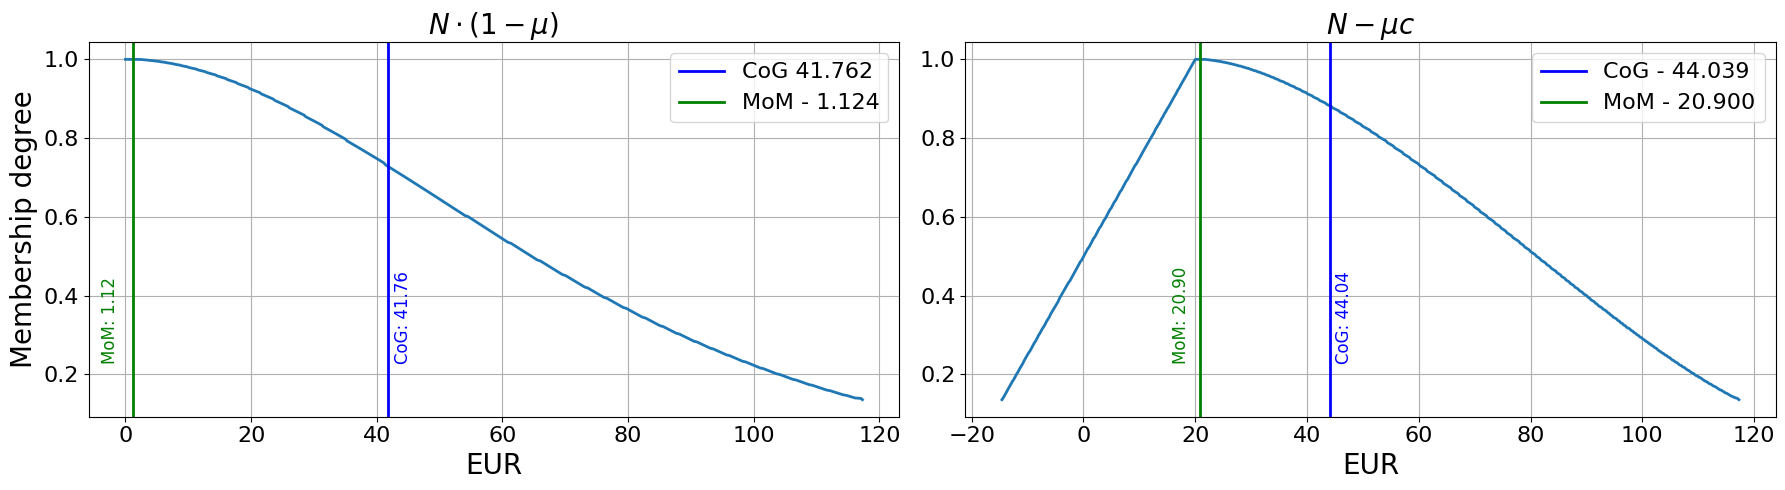

Plotting the payoff for differentt amounts of uncertainty. The choice between taking and not taking action is based on taking maximum of defuziffied values.


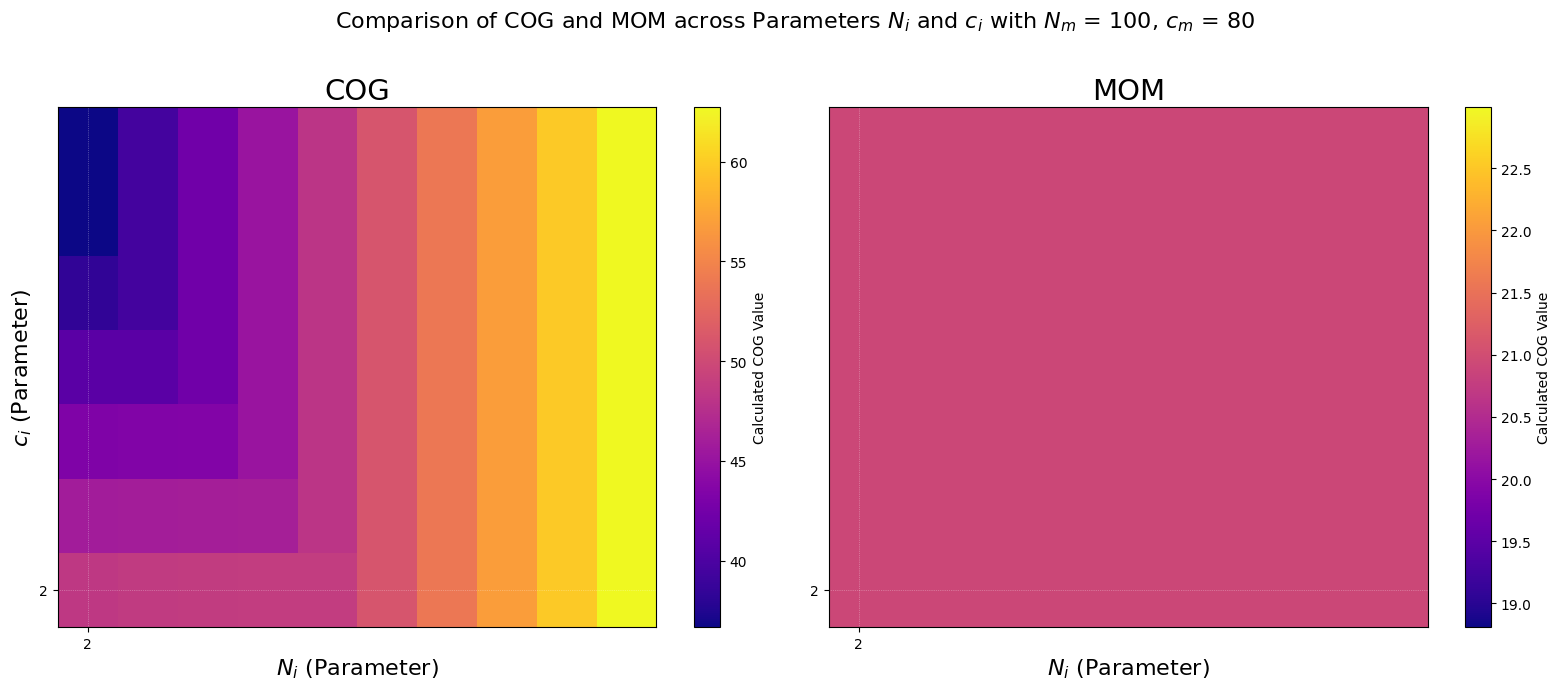

The membership function of sample L121: 


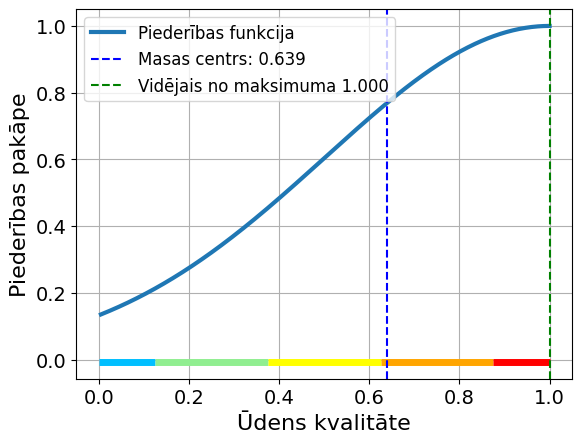

Plotting comparison between the payoff of perfomring an action and not performing an action:


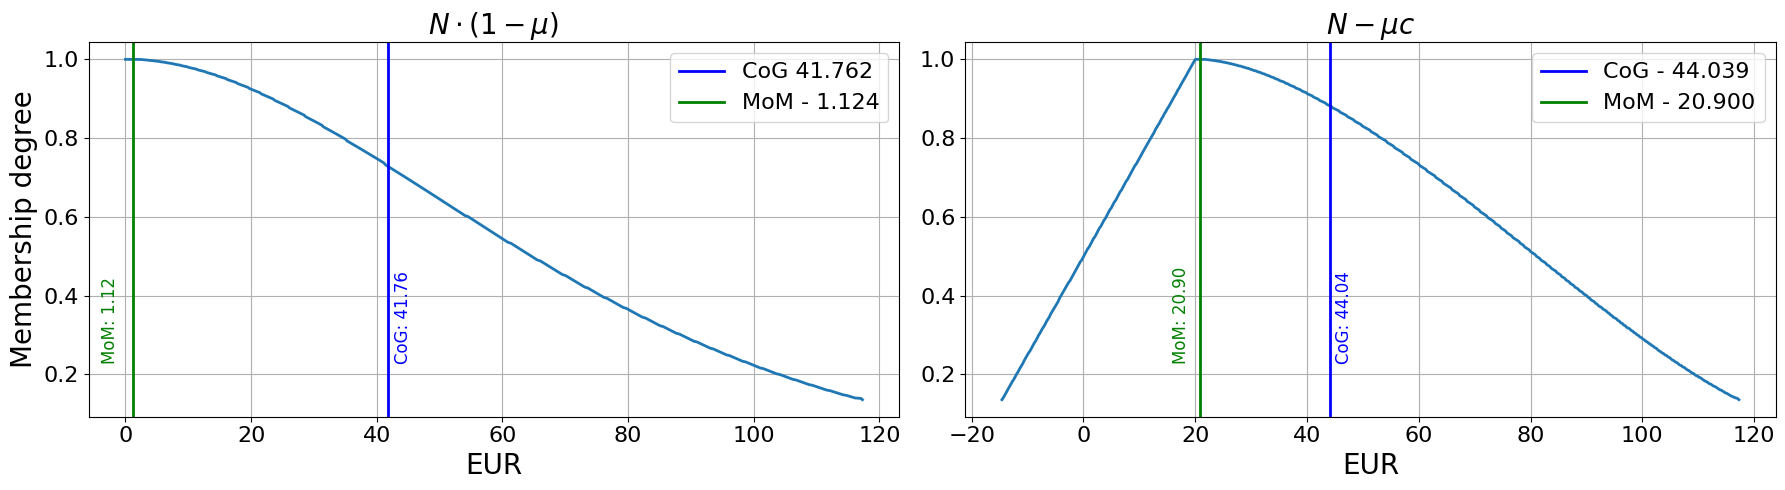

Plotting the payoff for differentt amounts of uncertainty. The choice between taking and not taking action is based on taking maximum of defuziffied values.


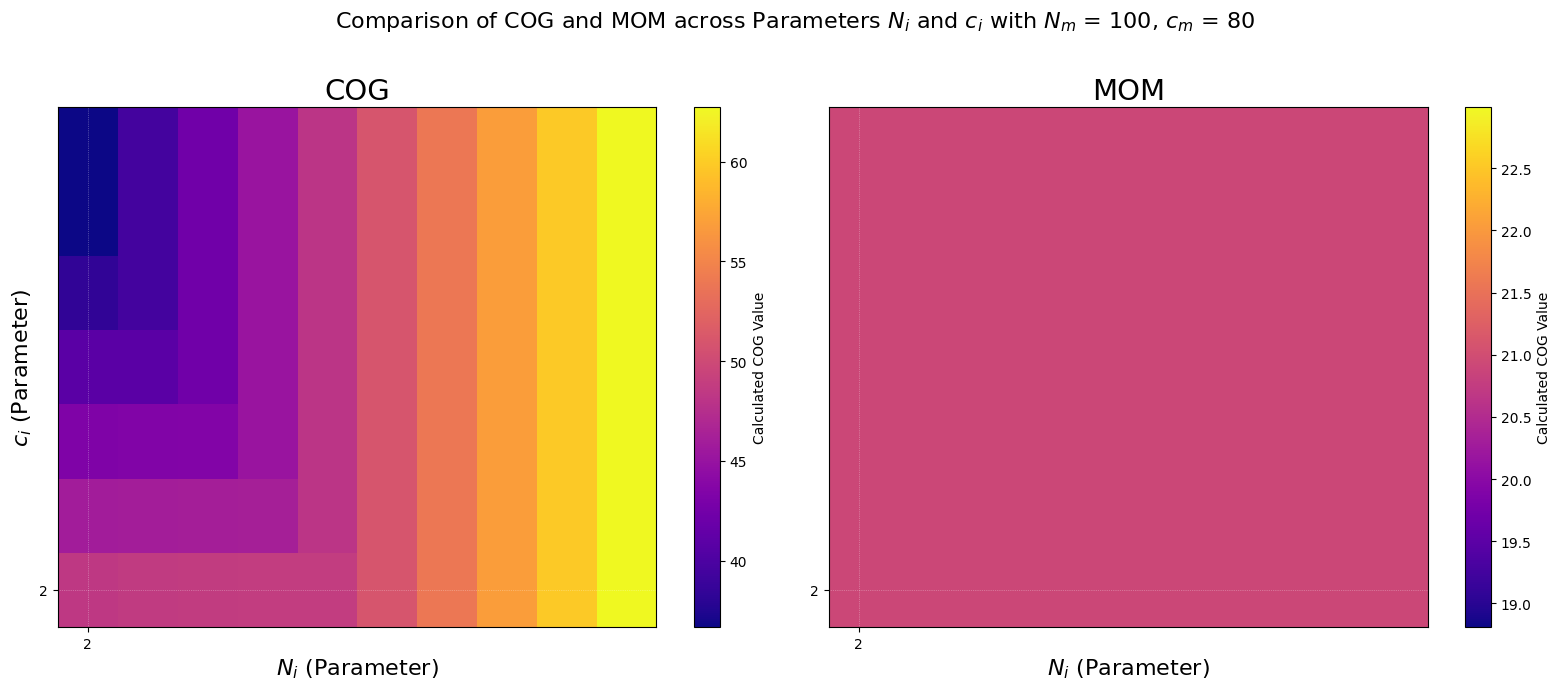

The membership function of sample V063DA: 


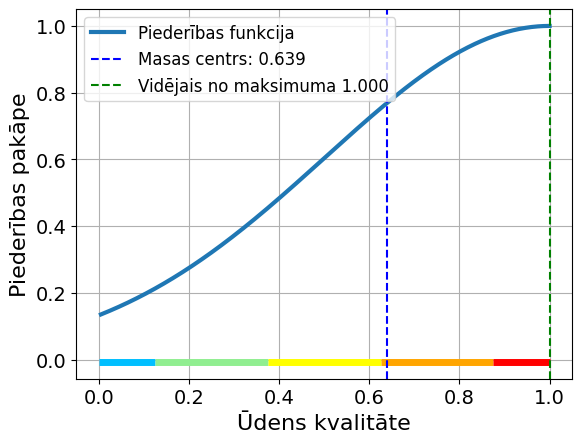

Plotting comparison between the payoff of perfomring an action and not performing an action:


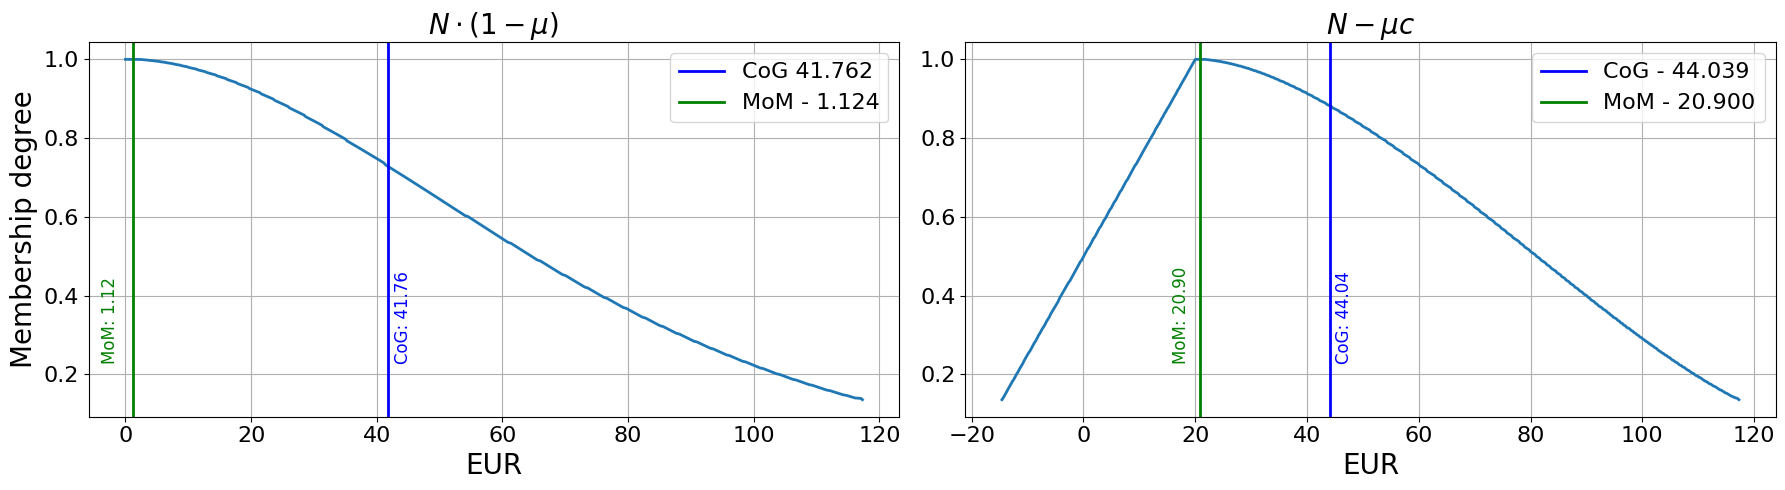

Plotting the payoff for differentt amounts of uncertainty. The choice between taking and not taking action is based on taking maximum of defuziffied values.


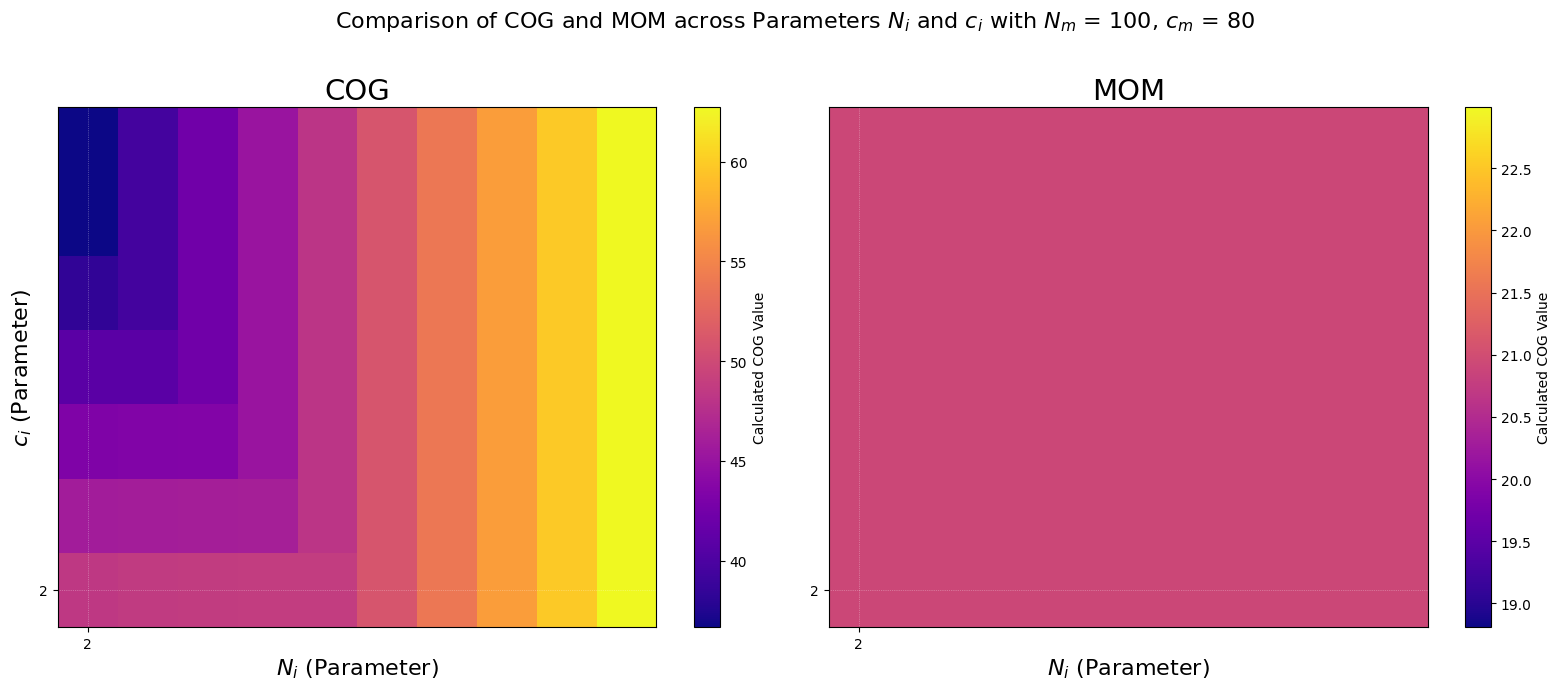

The membership function of sample V138: 


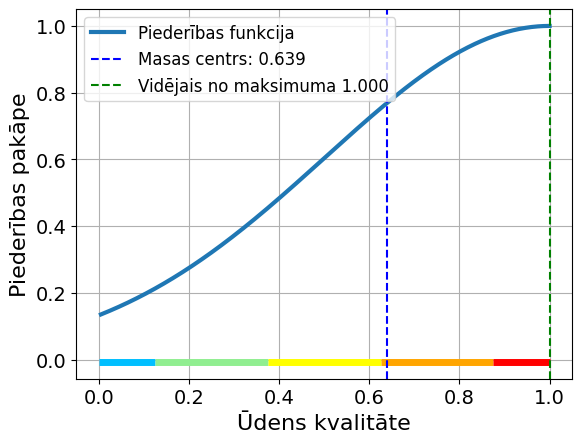

Plotting comparison between the payoff of perfomring an action and not performing an action:


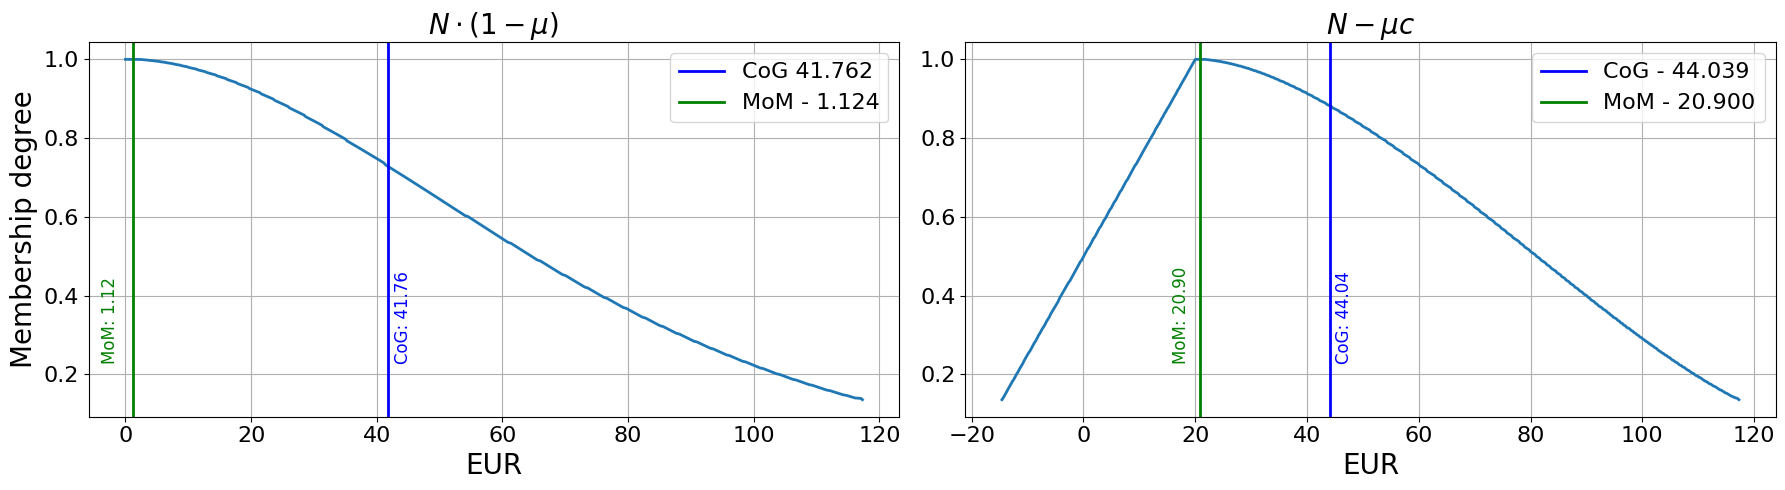

Plotting the payoff for differentt amounts of uncertainty. The choice between taking and not taking action is based on taking maximum of defuziffied values.


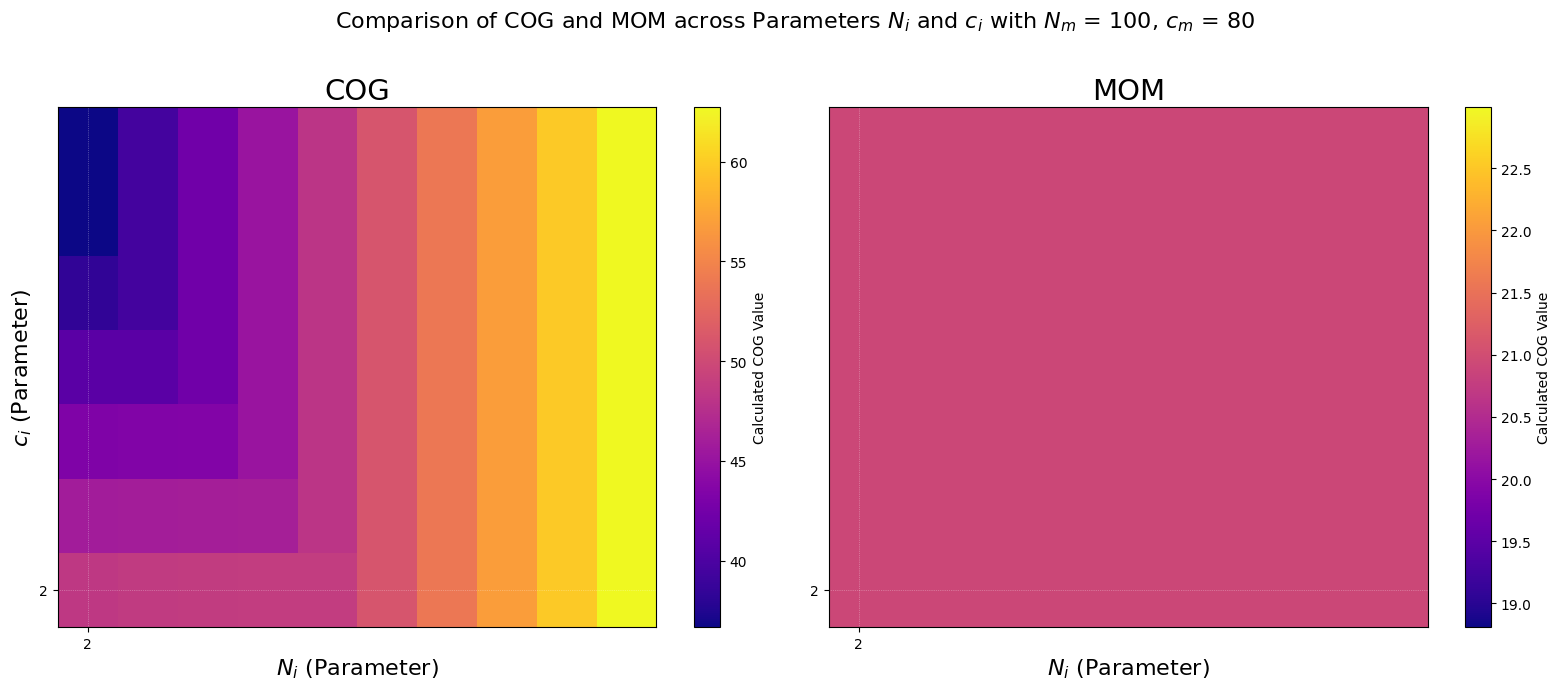

In [11]:
# Iterates trough the samples and performs inference and evaluation
for row in comparison_df.itertuples():
    data_type = row[2]
    sample_name = row[1]
    sample = row[2:-1]
 
    perform_infernece_and_evaluation_with_data(np.array(sample), step_size = 10,
                                               sample_name=sample_name,  Number_of_grid_points=500,
                                               type_of_tnorm='luk',
                                               payoff_membership_vaues = np.array([80, 100, 120]),
                                            cleaning_cost_membership_values = np.array([60, 80 , 100]))
    
    

Here is a simple exmaple of when the results produced by the inferece system are not satisfactory. Two dummy examples are made, where in first values, that correspong to having all *Very Bad* measurements, while the other sample has all values *Very Good* except for one, that is *Very Bad*. One can see, that for both of these samples, the final membership of water quality is the same. This is not satisfactory, because one water body is clearly cleaner, that the other, by having all but one *Very Good* qulaity.

The membership function of sample All bad sample: 


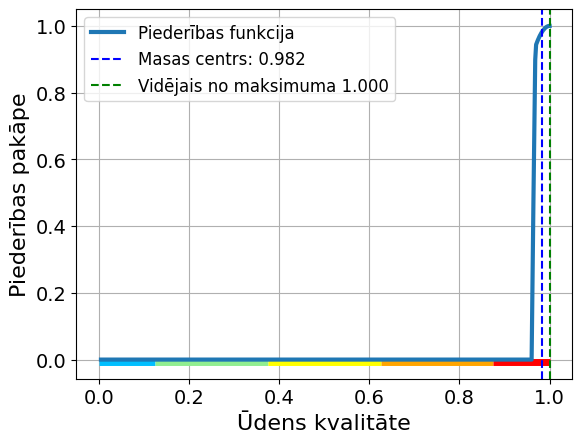

Plotting comparison between the payoff of perfomring an action and not performing an action:


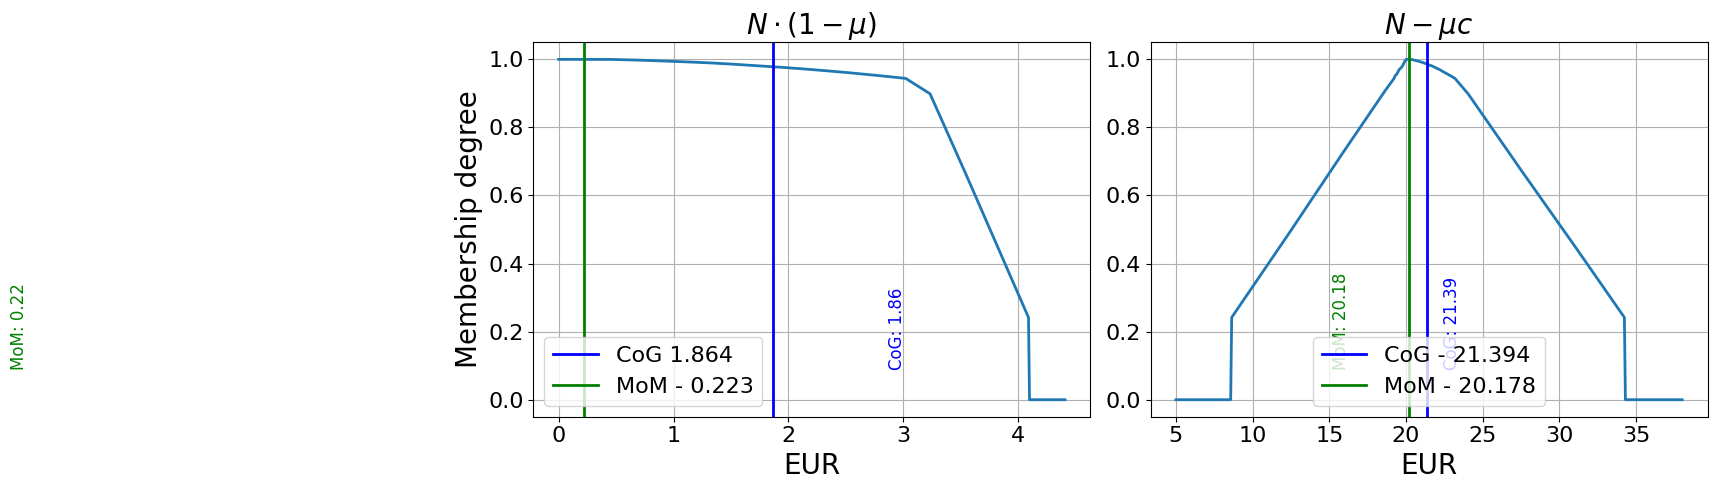

Plotting the payoff for differentt amounts of uncertainty. The choice between taking and not taking action is based on taking maximum of defuziffied values.


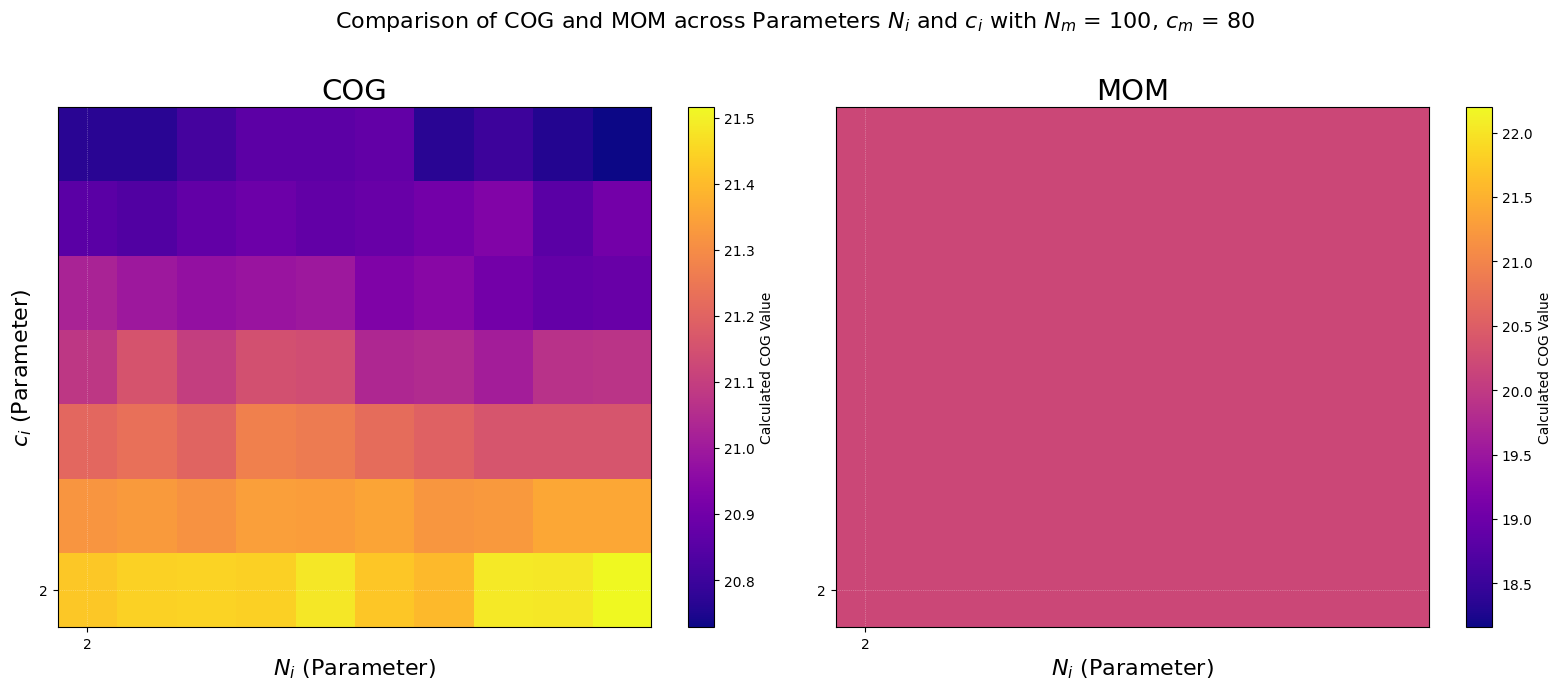

The membership function of sample All but one good sample: 


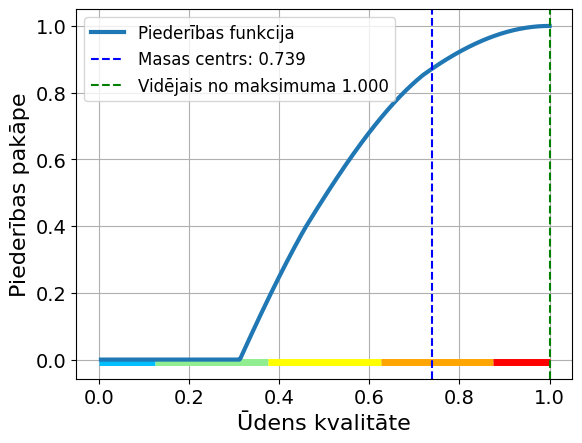

Plotting comparison between the payoff of perfomring an action and not performing an action:


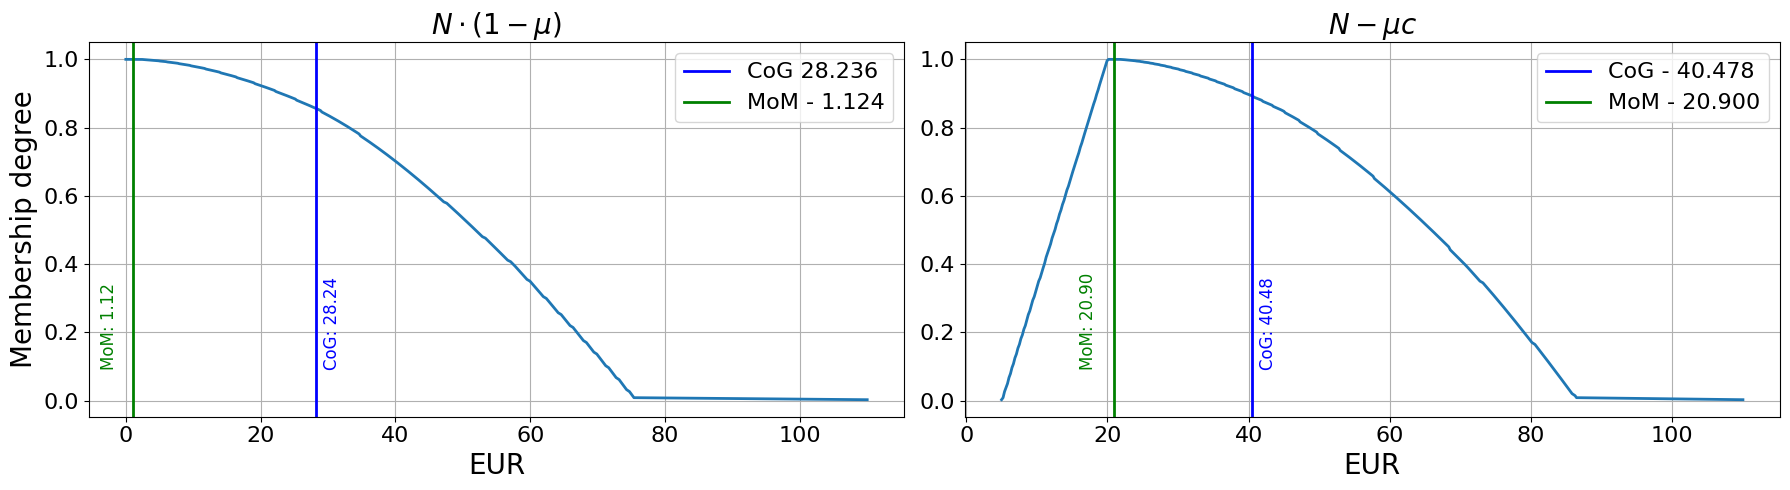

Plotting the payoff for differentt amounts of uncertainty. The choice between taking and not taking action is based on taking maximum of defuziffied values.


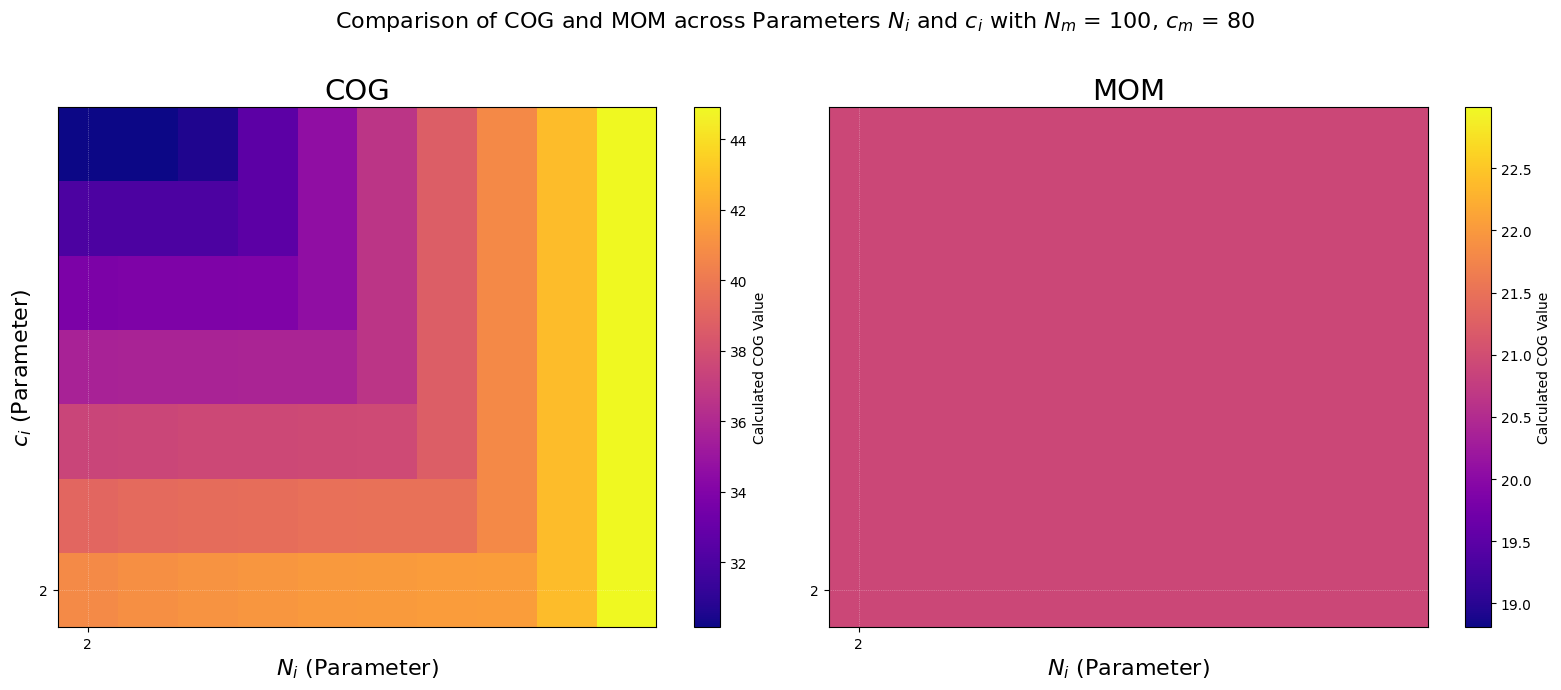

: 

In [ ]:

dummy_data_df= pd.DataFrame(columns=df_water_data.columns[-5:])
new_row_all_bad= {
    'BSP5': 3.75,
    'N_NH4+': 0.195,
    'N_total': 3.25,
    'O_2': 0,
    'P_total': 0.1275
}

dummy_data_df.loc[len(dummy_data_df)] = new_row_all_bad 

new_row_all_but_oneGood= {
    'BSP5': 1.75,
    'N_NH4+': 0.075,
    'N_total': 3.25,   # Nkop is bad, others are good
    'O_2': 9.0,
    'P_total': 0.0275
}
 
dummy_data_df.loc[len(dummy_data_df)] = new_row_all_but_oneGood

column_name_to_update = dummy_data_df.columns[3]
constant_sum = type_1_qualityGrid[3, -1] + type_1_qualityGrid[3, 0]
dummy_data_df[column_name_to_update] = constant_sum - dummy_data_df[column_name_to_update]
    
perform_infernece_and_evaluation_with_data(dummy_data_df.iloc[0].values, step_size = 10,
                                           Number_of_grid_points=500, sample_name='All bad sample',
                                           type_of_tnorm='luk', use_the_same_tnorm = True)
perform_infernece_and_evaluation_with_data(dummy_data_df.iloc[1].values,
                                           step_size = 10, Number_of_grid_points=500,
                                           sample_name='All but one good sample',
                                           type_of_tnorm='luk', use_the_same_tnorm = True)
